# Experimentos de la Primera Competencia

Todo sale del **ledger** (`../ledger/*.csv`, exportado de Postgres) y de los scores cacheados por semilla en
`../experimentos/`. Cada submit al bot `@competencia-uno` quedó registrado con su hipótesis, contra qué se
comparaba y la respuesta del bot (ganancia pública media y desvío entre archivos).

Dos reglas de lectura que valen para todo el cuaderno:

- La ganancia pública se calcula sobre ~25% de agosto. Entre semillas de un mismo modelo el desvío por archivo es
  **1,8–2,5**; con 5 archivos la media tiene sd ≈ 0,9 y con 20, ≈ 0,45. Nada que difiera menos de dos desvíos es
  una diferencia.
- Los submits de 5 semillas usan **las primeras 5 semillas**, que en los dos modelos de referencia salieron con suerte
  (+1,2 y +1,7 sobre la media de 20). La referencia honesta es la **media de 20 archivos**.


In [1]:
import sys, re, textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
sys.path.insert(0, str(Path("..").resolve()))
import v_estilo as ve
ve.aplicar()
mpl.rcParams.update({"font.size": 12, "axes.titlesize": 16, "legend.fontsize": 11, "figure.dpi": 100})
AZUL, NARANJA, AQUA, AMARILLO = ve.SERIES

def sin_marco(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    ax.grid(axis="y", color=ve.GRILLA, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

v = pd.read_csv("../ledger/v_submits.csv")
v = v[v.estado == "respondido"].copy()
v["enviado_en"] = pd.to_datetime(v.enviado_en, utc=True).dt.tz_convert("America/Argentina/Buenos_Aires")
v["corte"] = v.submit.str.extract(r"(\d{4,5})$").astype(float)
v.loc[v.corte.isna(), "corte"] = v.corte_envios
v["n"] = v.n_archivos.clip(lower=1)
v["err"] = v.public_gain_std / np.sqrt(v.n)
roto = v[v.public_gain_mean < 0]
print(f"{len(v)} submits respondidos; {len(roto)} roto (se excluye): {roto.submit.tolist()}")
v = v[v.public_gain_mean > 0]
fechados = v[v.enviado_en.notna()].copy()     # enviado_en = hora del mensaje al bot en Zulip
print(f"{len(fechados)} con fecha de envío")

99 submits respondidos; 1 roto (se excluye): ['c118_v101_9000']
98 con fecha de envío


## 1. El público, submit por submit

Cada punto es un submit; el tamaño dice cuántos archivos llevaba (1, 5, 10 o 20) y la barra es el error estándar
de la media entre archivos. El salto del 7 de octubre a la noche es **lags y deltas de orden 1 y 2 de las 150
variables + la receta de hiperparámetros de la cátedra**: lo único que movió el público más que el ruido.

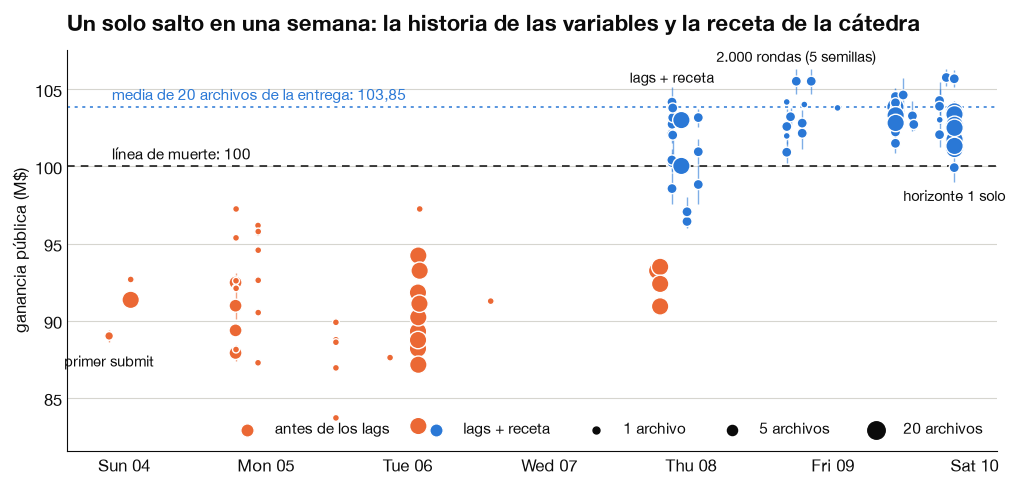

In [2]:
f = fechados.sort_values("enviado_en")
era = np.where(f.enviado_en < pd.Timestamp("2026-10-07 20:00", tz="America/Argentina/Buenos_Aires"),
               "antes de los lags", "lags + receta")
fig, ax = plt.subplots(figsize=(12, 5.2))
for nombre, color in (("antes de los lags", NARANJA), ("lags + receta", AZUL)):
    m = era == nombre
    ax.errorbar(f.enviado_en[m], f.public_gain_mean[m], yerr=f.err[m], fmt="none", ecolor=color, elinewidth=1, alpha=0.6, zorder=2)
    ax.scatter(f.enviado_en[m], f.public_gain_mean[m], s=18 + 7 * f.n[m], color=color, edgecolor="white", linewidth=1, label=nombre, zorder=3)
ax.axhline(100, color=ve.TINTA, linestyle=(0, (5, 4)), linewidth=1.1, zorder=1)
ax.annotate("línea de muerte: 100", (f.enviado_en.min(), 100), xytext=(2, 5), textcoords="offset points", fontsize=11)
ax.axhline(103.85, color=AZUL, linestyle=(0, (2, 3)), linewidth=1.1, zorder=1)
ax.annotate("media de 20 archivos de la entrega: 103,85", (f.enviado_en.min(), 103.85), xytext=(2, 5), textcoords="offset points", fontsize=11, color=AZUL)
for s, txt, dy in (("c100_esqueleto", "primer submit", -22), ("c201_lags_14000", "lags + receta", 14), ("c241_rondas2000_14000", "2.000 rondas (5 semillas)", 14), ("c270_h1_0307_14000", "horizonte 1 solo", -24)):
    r = f[f.submit == s].iloc[0]
    ax.annotate(txt, (r.enviado_en, r.public_gain_mean), xytext=(0, dy), textcoords="offset points", ha="center", fontsize=10.5, color=ve.TINTA)
for n, x in ((1, 0.60), (5, 0.68), (20, 0.78)):
    ax.scatter([], [], s=18 + 7 * n, color=ve.TINTA_MUDA, label=f"{n} archivo{'s' if n > 1 else ''}")
ax.legend(loc="lower right", ncol=5, frameon=False)
ax.set_ylabel("ganancia pública (M$)"); ax.set_xlabel("")
ax.set_title("Un solo salto en una semana: la historia de las variables y la receta de la cátedra")
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%a %d", tz="America/Argentina/Buenos_Aires"))
sin_marco(ax); 
plt.show()

## 2. El corte óptimo se corre con el modelo

La ganancia pública según cuántos clientes se envían. Cada curva es un modelo distinto, **medido con 20 archivos
por punto** (una semilla por archivo), así que la sd de cada punto es ≈ 0,45. El modelo base tenía su óptimo en
9.000; con lags y receta el óptimo pasa a 14.000, y 2.000 rondas están por encima de 1.000 **en los cinco cortes**.

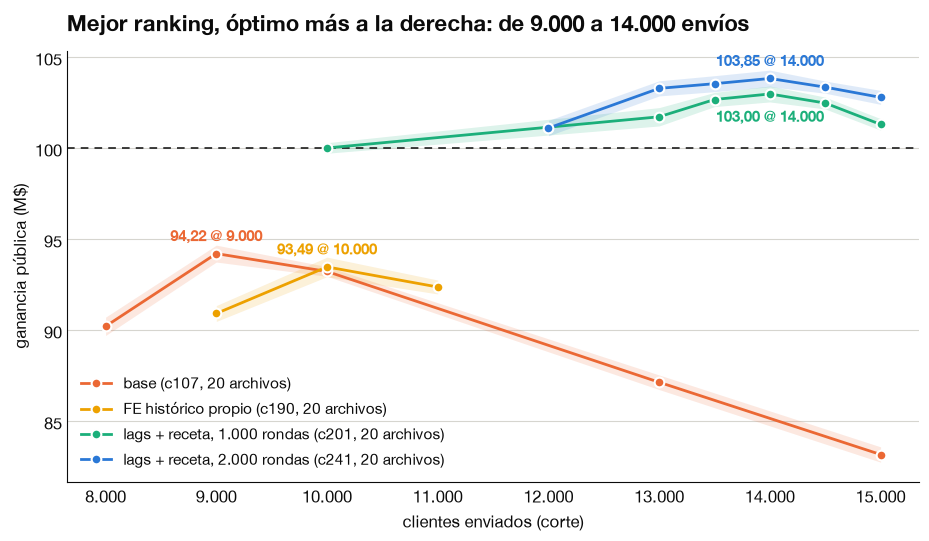

In [3]:
curvas = {
    "base (c107, 20 archivos)": ["c152_corte8000", "c152_corte9000", "c191_base10000", "c152_corte13000", "c152_corte15000"],
    "FE histórico propio (c190, 20 archivos)": ["c190_fe3_9000", "c190_fe3_10000", "c190_fe3_11000"],
    "lags + receta, 1.000 rondas (c201, 20 archivos)": [s for s in v.submit if s.startswith("c201_lags20_")],
    "lags + receta, 2.000 rondas (c241, 20 archivos)": [s for s in v.submit if s.startswith("c241_rondas2000_20_")],
}
fig, ax = plt.subplots(figsize=(11, 5.6))
for i, ((nombre, subs), color) in enumerate(zip(curvas.items(), (NARANJA, AMARILLO, AQUA, AZUL))):
    d = v[v.submit.isin(subs)].sort_values("corte")
    ax.fill_between(d.corte, d.public_gain_mean - d.err, d.public_gain_mean + d.err, color=color, alpha=0.15, linewidth=0)
    ax.plot(d.corte, d.public_gain_mean, color=color, linewidth=2, marker="o", markersize=7, markeredgecolor="white", markeredgewidth=1.5, label=nombre, zorder=3)
    pico = d.loc[d.public_gain_mean.idxmax()]
    ax.annotate(f"{ve.num(pico.public_gain_mean, 2)} @ {ve.num(pico.corte)}", (pico.corte, pico.public_gain_mean), xytext=(0, 9 if i != 2 else -20), textcoords="offset points", ha="center", fontsize=10.5, color=color, fontweight="bold")
ax.axhline(100, color=ve.TINTA, linestyle=(0, (5, 4)), linewidth=1.1, zorder=1)
ax.set_xlabel("clientes enviados (corte)"); ax.set_ylabel("ganancia pública (M$)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: ve.num(x)))
ax.legend(loc="lower left", frameon=False)
ax.set_title("Mejor ranking, óptimo más a la derecha: de 9.000 a 14.000 envíos")
sin_marco(ax); 
plt.show()

## 3. Todo lo que se probó encima de la receta, contra la referencia honesta

Cada variante se midió con **las mismas 5 primeras semillas** que la receta a 2.000 rondas (c241), a corte 14.000.
La línea punteada es c241 con esas 5 semillas (105,51); la franja va de la media de 20 de c241 (103,85) a ese
valor: **lo que cae adentro no se distingue de la receta**. Barras: ±1,96 errores estándar (5 archivos).

Ninguna variante sale de la franja por arriba. Varias salen por abajo: el hessiano en las dos direcciones, la
reducción de dimensionalidad por importancia en las dos intensidades, el horizonte 1 solo.

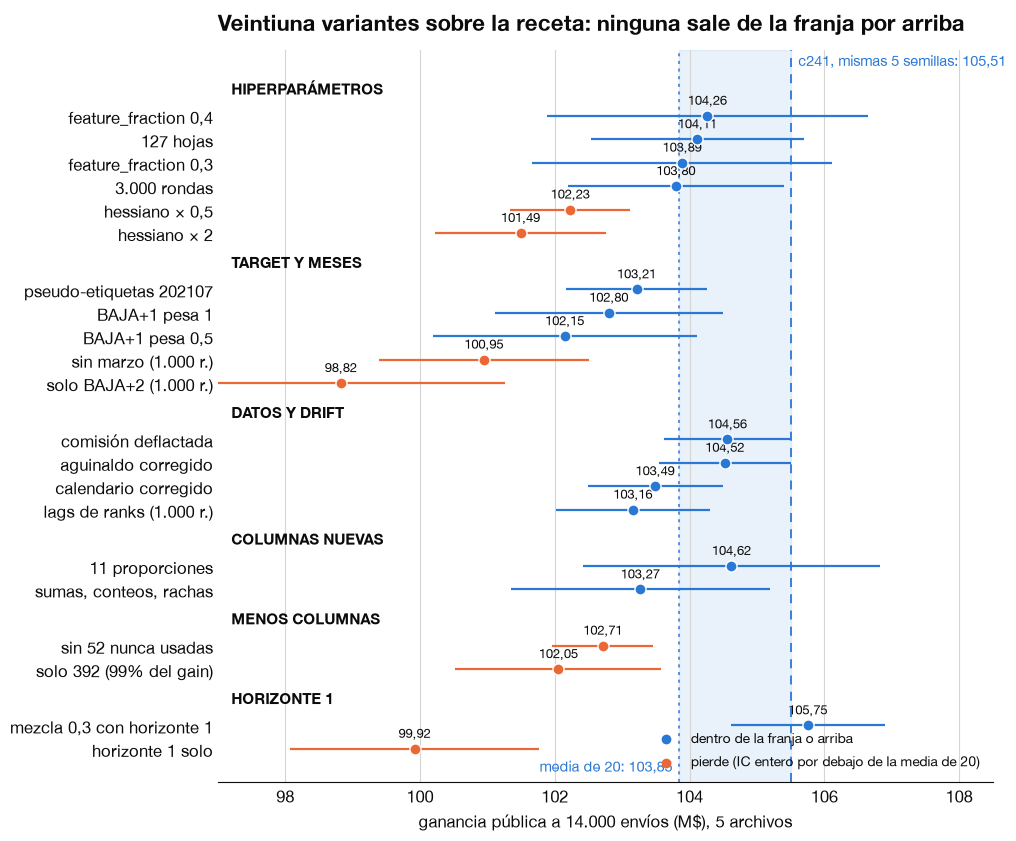

In [4]:
variantes = [
    ("Hiperparámetros", "c246_rondas3000_14000", "3.000 rondas"),
    ("Hiperparámetros", "c249_hojas127_14000", "127 hojas"),
    ("Hiperparámetros", "c264_ff04_14000", "feature_fraction 0,4"),
    ("Hiperparámetros", "c265_ff03_14000", "feature_fraction 0,3"),
    ("Hiperparámetros", "c247_hess05_14000", "hessiano × 0,5"),
    ("Hiperparámetros", "c248_hess2_14000", "hessiano × 2"),
    ("Target y meses", "c242_peso05_14000", "BAJA+1 pesa 0,5"),
    ("Target y meses", "c243_baja12_14000", "BAJA+1 pesa 1"),
    ("Target y meses", "c213_lags_baja2_14000", "solo BAJA+2 (1.000 r.)"),
    ("Target y meses", "c214_lags_sin03_14000", "sin marzo (1.000 r.)"),
    ("Target y meses", "c240_pu2500_14000", "pseudo-etiquetas 202107"),
    ("Datos y drift", "c251_comdefl2000_14000", "comisión deflactada"),
    ("Datos y drift", "c253_aguinaldo2000_14000", "aguinaldo corregido"),
    ("Datos y drift", "c255_calendario2000_14000", "calendario corregido"),
    ("Datos y drift", "c215_lagsrank_14000", "lags de ranks (1.000 r.)"),
    ("Columnas nuevas", "c260_props2000_14000", "11 proporciones"),
    ("Columnas nuevas", "c261_agregados2000_14000", "sumas, conteos, rachas"),
    ("Menos columnas", "c262_sin_muertas_14000", "sin 52 nunca usadas"),
    ("Menos columnas", "c263_gain99_14000", "solo 392 (99% del gain)"),
    ("Horizonte 1", "c271_mezcla_h1_p30_14000", "mezcla 0,3 con horizonte 1"),
    ("Horizonte 1", "c270_h1_0307_14000", "horizonte 1 solo"),
]
ref5, ref20 = 105.512, 103.847
rows = []
for g, s, et in variantes:
    r = v[v.submit == s].iloc[0]
    rows.append((g, et, r.public_gain_mean, 1.96 * r.err))
t = pd.DataFrame(rows, columns=["grupo", "variante", "media", "ic"])
orden_g = ["Hiperparámetros", "Target y meses", "Datos y drift", "Columnas nuevas", "Menos columnas", "Horizonte 1"]
t["g"] = pd.Categorical(t.grupo, orden_g); t = t.sort_values(["g", "media"], ascending=[True, False]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 9.5))
ys, labels, y = [], [], 0
for g, bloque in t.groupby("g", sort=True, observed=True):
    ax.text(97.2, y + 0.15, g.upper(), fontsize=10.5, fontweight="bold", color=ve.TINTA, va="center")
    y -= 1
    for _, r in bloque.iterrows():
        fuera = r.media + r.ic < ref20
        c = NARANJA if fuera else AZUL
        ax.errorbar(r.media, y, xerr=r.ic, fmt="o", color=c, ecolor=c, elinewidth=1.6, capsize=0, markersize=8, markeredgecolor="white", zorder=3)
        ax.annotate(ve.num(r.media, 2), (r.media, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9.5, color=ve.TINTA)
        ys.append(y); labels.append(r.variante); y -= 1
    y -= 0.4
ax.axvspan(ref20, ref5, color=AZUL, alpha=0.10, zorder=0)
ax.axvline(ref5, color=AZUL, linestyle=(0, (5, 4)), linewidth=1.3, zorder=1)
ax.axvline(ref20, color=AZUL, linestyle=(0, (2, 3)), linewidth=1.1, zorder=1)
ax.text(ref5 + 0.1, 1.0, "c241, mismas 5 semillas: 105,51", color=AZUL, fontsize=10.5, ha="left", va="bottom")
ax.text(ref20 - 0.1, y + 0.3, "media de 20: 103,85", color=AZUL, fontsize=10.5, ha="right", va="bottom")
ax.set_yticks(ys, labels); ax.set_ylim(y, 1.8); ax.set_xlim(97, 108.5)
ax.set_xlabel("ganancia pública a 14.000 envíos (M$), 5 archivos")
ax.grid(axis="x", color=ve.GRILLA, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(length=0)
ax.scatter([], [], color=AZUL, label="dentro de la franja o arriba"); ax.scatter([], [], color=NARANJA, label="pierde (IC entero por debajo de la media de 20)")
ax.legend(loc="lower right", frameon=False, fontsize=10)
ax.set_title("Veintiuna variantes sobre la receta: ninguna sale de la franja por arriba")
plt.show()

## 3b. Más columnas, menos columnas: qué pasó con el público

La misma receta con distinta cantidad de predictoras, todas a 14.000 envíos y con las mismas 5 semillas (salvo donde
se indica). Las 750 son las 150 crudas más lag 1, delta 1, lag 2 y delta 2 de cada una. Agregar columnas de negocio
(proporciones, sumas, conteos, rachas) no movió el público aunque se llevaron el 20–29% del gain; sacar columnas por
importancia perdió en las dos intensidades. A la izquierda, con los hiperparámetros viejos y a 9.000–10.000 envíos,
la misma historia: el FE propio de 228 columnas perdió contra las 150 crudas.

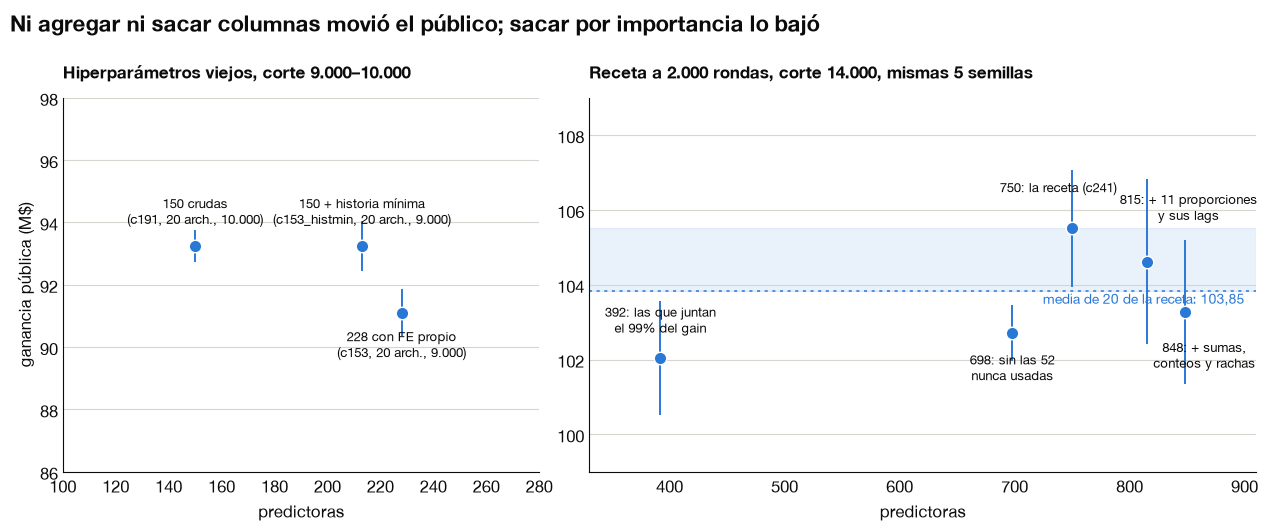

In [5]:
izq = [("150 crudas\n(c191, 20 arch., 10.000)", "c191_base10000", 150, (0, 16)), ("228 con FE propio\n(c153, 20 arch., 9.000)", "c153_fe228", 228, (0, -32)),
       ("150 + historia mínima\n(c153_histmin, 20 arch., 9.000)", "c153_histmin9k", 150 + 21 * 3, (0, 16))]
der = [("392: las que juntan\nel 99% del gain", "c263_gain99_14000", 392, (0, 18)), ("698: sin las 52\nnunca usadas", "c262_sin_muertas_14000", 698, (0, -34)),
       ("750: la receta (c241)", "c241_rondas2000_14000", 750, (-10, 26)), ("815: + 11 proporciones\ny sus lags", "c260_props2000_14000", 815, (30, 30)),
       ("848: + sumas,\nconteos y rachas", "c261_agregados2000_14000", 848, (14, -40))]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1, 1.4]})
for ax, lista, titulo in ((a1, izq, "Hiperparámetros viejos, corte 9.000–10.000"), (a2, der, "Receta a 2.000 rondas, corte 14.000, mismas 5 semillas")):
    for et, s, ncol, off in lista:
        r = v[v.submit == s].iloc[0]
        ax.errorbar(ncol, r.public_gain_mean, yerr=1.96 * r.err, fmt="o", color=AZUL, ecolor=AZUL, elinewidth=1.4, markersize=9, markeredgecolor="white", zorder=3)
        ax.annotate(et, (ncol, r.public_gain_mean), xytext=off, textcoords="offset points", ha="center", fontsize=9.5)
    ax.set_xlabel("predictoras"); ax.set_title(titulo, fontsize=12.5); sin_marco(ax)
a1.set_ylabel("ganancia pública (M$)"); a1.set_ylim(86, 98); a1.set_xlim(100, 280)
a2.axhspan(ref20, ref5, color=AZUL, alpha=0.10, zorder=0); a2.axhline(ref20, color=AZUL, linestyle=(0, (2, 3)), linewidth=1.1)
a2.text(900, ref20, "media de 20 de la receta: 103,85", color=AZUL, fontsize=10, va="top", ha="right")
a2.set_ylim(99, 109); a2.set_xlim(330, 910)
fig.suptitle("Ni agregar ni sacar columnas movió el público; sacar por importancia lo bajó", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(); 
plt.show()

## 4. Las primeras cinco semillas tuvieron suerte

El mismo modelo, medido con sus primeras 5 semillas y con las 20. En los dos modelos de referencia las 5 primeras
están arriba de la media de 20. Es la razón por la que ninguna variante de 5 semillas se compara contra 105,51 sino
contra la franja. El ensamble de las 20 (un archivo) cae donde cae la media de 20: el ensamble no "gana", reduce varianza.

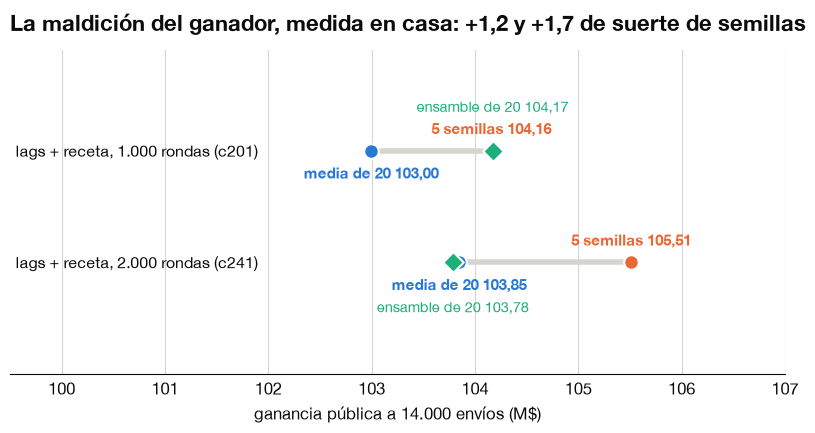

In [6]:
pares = [("lags + receta, 1.000 rondas (c201)", "c201_lags_14000", "c201_lags20_14000", "c201_lags_ens20_14000"),
         ("lags + receta, 2.000 rondas (c241)", "c241_rondas2000_14000", "c241_rondas2000_20_14000", "c241_rondas2000_ens20_14000")]
fig, ax = plt.subplots(figsize=(10, 4.2))
for i, (nombre, s5, s20, sens) in enumerate(pares):
    a, b, e = (v[v.submit == s].public_gain_mean.iloc[0] for s in (s5, s20, sens))
    yy = 1 - i
    ax.plot([b, a], [yy, yy], color=ve.GRILLA, linewidth=4, zorder=1, solid_capstyle="round")
    ax.scatter([a], [yy], s=110, color=NARANJA, zorder=3, edgecolor="white", linewidth=1.5)
    ax.scatter([b], [yy], s=110, color=AZUL, zorder=3, edgecolor="white", linewidth=1.5)
    ax.scatter([e], [yy], s=110, marker="D", color=AQUA, zorder=3, edgecolor="white", linewidth=1.5)
    ax.annotate(f"5 semillas {ve.num(a, 2)}", (a, yy), xytext=(0, 12), textcoords="offset points", ha="center", fontsize=10.5, color=NARANJA, fontweight="bold")
    ax.annotate(f"media de 20 {ve.num(b, 2)}", (b, yy), xytext=(0, -20), textcoords="offset points", ha="center", fontsize=10.5, color=AZUL, fontweight="bold")
    ax.annotate(f"ensamble de 20 {ve.num(e, 2)}", (e, yy), xytext=(0, 28 if abs(e - a) < abs(e - b) else -36), textcoords="offset points", ha="center", fontsize=10.5, color=AQUA)
    ax.text(101.9, yy, nombre, ha="right", va="center", fontsize=11.5)
ax.set_xlim(99.5, 107); ax.set_ylim(-1.0, 1.9); ax.set_yticks([])
ax.set_xlabel("ganancia pública a 14.000 envíos (M$)")
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(length=0); ax.grid(axis="x", color=ve.GRILLA, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.set_title("La maldición del ganador, medida en casa: +1,2 y +1,7 de suerte de semillas")
plt.show()

## 5. Un segundo modelo, mezclado de a poco

Un modelo de **horizonte 1** (target BAJA+1 solo, entrenado hasta julio, que tiene esa etiqueta completa) mezclado por
rango con c241, **semilla a semilla**: cada archivo de la mezcla usa la misma semilla que el archivo de c241 con el
que se compara, así que la comparación es pareada y el ruido de semillas se cancela. La curva es plana hasta peso
0,5 y se hunde después: el segundo modelo no agrega información que el target con pesos no tuviera.

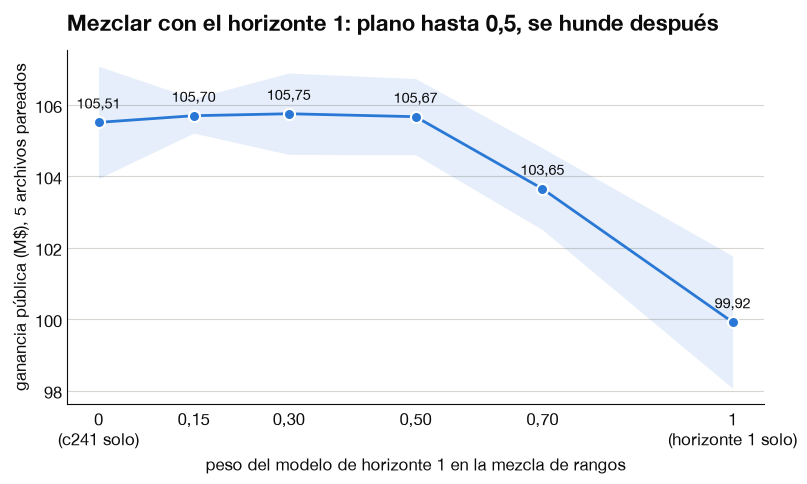

In [7]:
pesos = [(0, "c241_rondas2000_14000"), (0.15, "c271_mezcla_h1_p15_14000"), (0.30, "c271_mezcla_h1_p30_14000"),
         (0.50, "c271_mezcla_h1_p50_14000"), (0.70, "c271_mezcla_h1_p70_14000"), (1.0, "c270_h1_0307_14000")]
d = pd.DataFrame([(p, v[v.submit == s].public_gain_mean.iloc[0], v[v.submit == s].err.iloc[0]) for p, s in pesos], columns=["peso", "media", "err"])
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.fill_between(d.peso, d.media - 1.96 * d.err, d.media + 1.96 * d.err, color=AZUL, alpha=0.12, linewidth=0)
ax.plot(d.peso, d.media, color=AZUL, linewidth=2, marker="o", markersize=8, markeredgecolor="white", markeredgewidth=1.5, zorder=3)
for _, r in d.iterrows():
    ax.annotate(ve.num(r.media, 2), (r.peso, r.media), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=10.5)
ax.set_xticks(d.peso, ["0\n(c241 solo)", "0,15", "0,30", "0,50", "0,70", "1\n(horizonte 1 solo)"])
ax.set_xlabel("peso del modelo de horizonte 1 en la mezcla de rangos"); ax.set_ylabel("ganancia pública (M$), 5 archivos pareados")
ax.set_title("Mezclar con el horizonte 1: plano hasta 0,5, se hunde después")
sin_marco(ax); 
plt.show()

## 6. Qué mira el modelo

Importancia por ganancia (gain) sumada en los 20 modelos de la entrega, 750 columnas. La curva acumulada muestra la
concentración: 24 columnas explican la mitad del gain y 392 el 99%; 52 nunca se usaron para partir. Y sin embargo
sacar esas columnas **perdió** (sección 3): en el muestreo de columnas de cada árbol sirven de ruido útil.

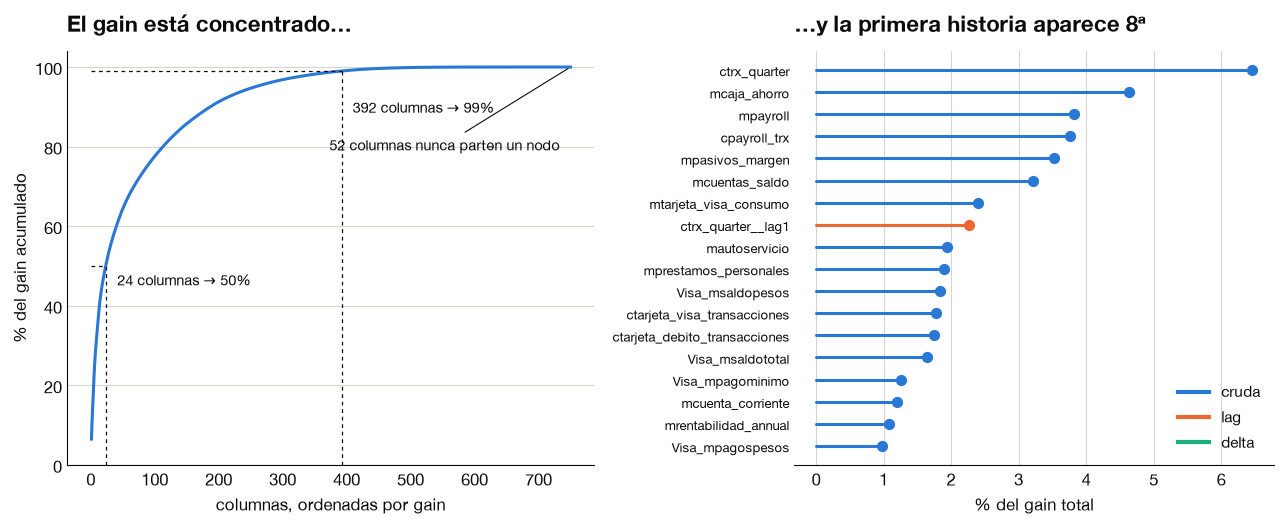

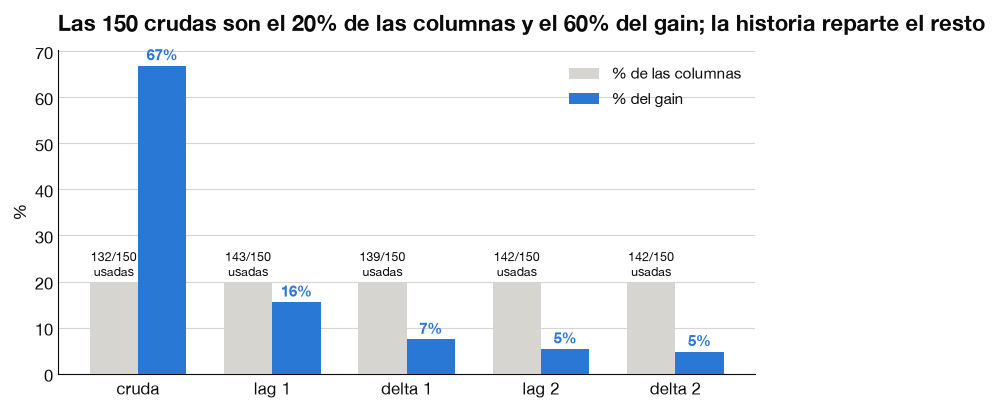

In [8]:
imp = pd.read_csv("../experimentos/c241_rondas2000/importancia_20.csv").sort_values("gain", ascending=False).reset_index(drop=True)
imp["tipo"] = np.select([imp.col.str.endswith("__lag1") | imp.col.str.endswith("__lag2"), imp.col.str.contains("__delta")], ["lag", "delta"], "cruda")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.1, 1]})
x = np.arange(1, len(imp) + 1)
a1.plot(x, imp.gain_acum, color=AZUL, linewidth=2.2)
for n, frac in ((24, 50), (392, 99)):
    a1.plot([n, n], [0, frac], color=ve.TINTA, linewidth=0.9, linestyle=(0, (3, 3)))
    a1.plot([0, n], [frac, frac], color=ve.TINTA, linewidth=0.9, linestyle=(0, (3, 3)))
    a1.annotate(f"{n} columnas → {frac}%", (n, frac), xytext=(8, -14 if n < 100 else -30), textcoords="offset points", fontsize=10.5)
nunca = int((imp.gain == 0).sum())
a1.annotate(f"{nunca} columnas nunca parten un nodo", (750, 100), xytext=(-8, -60), textcoords="offset points", ha="right", fontsize=10.5, arrowprops=dict(arrowstyle="-", color=ve.TINTA, lw=0.8))
a1.set_xlabel("columnas, ordenadas por gain"); a1.set_ylabel("% del gain acumulado"); a1.set_ylim(0, 104)
a1.set_title("El gain está concentrado…"); sin_marco(a1)
top = imp.head(18).iloc[::-1]
colores = {"cruda": AZUL, "lag": NARANJA, "delta": AQUA}
for i, r in enumerate(top.itertuples()):
    a2.plot([0, r.gain_pct], [i, i], color=colores[r.tipo], linewidth=2.2, solid_capstyle="round")
    a2.scatter([r.gain_pct], [i], color=colores[r.tipo], s=50, zorder=3)
a2.set_yticks(range(len(top)), top.col, fontsize=9.5)
a2.set_xlabel("% del gain total")
for k, c in colores.items(): a2.plot([], [], color=c, linewidth=3, label=k)
a2.legend(loc="lower right", frameon=False)
a2.set_title("…y la primera historia aparece 8ª")
for s in ("top", "right", "left"): a2.spines[s].set_visible(False)
a2.tick_params(length=0); a2.grid(axis="x", color=ve.GRILLA, linewidth=0.8, zorder=0); a2.set_axisbelow(True)
fig.tight_layout(); 
plt.show()

tipo5 = np.select([imp.col.str.endswith("__lag1"), imp.col.str.endswith("__lag2"), imp.col.str.endswith("__delta1"), imp.col.str.endswith("__delta2")], ["lag 1", "lag 2", "delta 1", "delta 2"], "cruda")
g = pd.DataFrame({"tipo": tipo5, "gain": imp.gain_pct, "usada": imp.gain > 0}).groupby("tipo").agg(gain=("gain", "sum"), n=("gain", "size"), usadas=("usada", "sum")).loc[["cruda", "lag 1", "delta 1", "lag 2", "delta 2"]]
g["cols"] = 100 * g.n / g.n.sum()
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(g)); w = 0.36
ax.bar(x - w / 2, g.cols, width=w, color=ve.GRILLA, zorder=3, label="% de las columnas")
ax.bar(x + w / 2, g.gain, width=w, color=AZUL, zorder=3, label="% del gain")
for xi, (c, gg, u, n) in enumerate(zip(g.cols, g.gain, g.usadas, g.n)):
    ax.annotate(f"{gg:.0f}%", (xi + w / 2, gg), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5, color=AZUL, fontweight="bold")
    ax.annotate(f"{u}/{n}\nusadas", (xi - w / 2, c), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9, color=ve.TINTA)
ax.set_xticks(x, g.index); ax.set_ylabel("%"); ax.legend(loc="upper right", frameon=False)
ax.set_title("Las 150 crudas son el 20% de las columnas y el 60% del gain; la historia reparte el resto")
sin_marco(ax); 
plt.show()

## 7. Cuánto cambia la lista con la semilla

Los 20 modelos de la entrega eligen cada uno 14.000 clientes. ¿Cuántos clientes están en las 20 listas? ¿Cuántos
entran y salen según la semilla? Es la medida de cuánto "borde" tiene el corte, y la razón de ensamblar por rango.

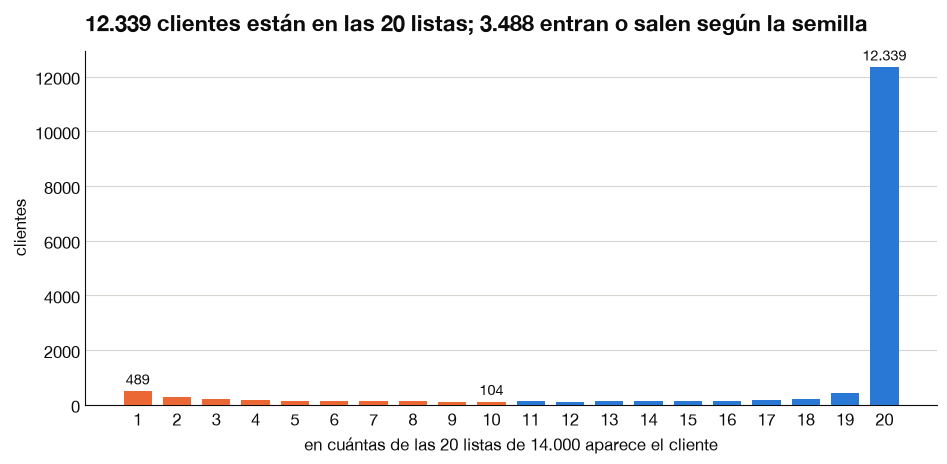

clientes elegidos por alguna semilla: 15,827; por las 20: 12,339; por 10 o menos: 1,905


In [9]:
import glob
scores = {Path(p).stem.split("_s")[-1]: pd.read_parquet(p) for p in sorted(glob.glob("../experimentos/c241_rondas2000/scores_202108_s*.parquet"))}
ids = next(iter(scores.values())).numero_de_cliente.to_numpy()
K = 14_000
conteo = np.zeros(len(ids), dtype=int)
for t in scores.values():
    conteo[np.argsort(-t.score.to_numpy(), kind="stable")[:K]] += 1
h = np.bincount(conteo, minlength=21)
fig, ax = plt.subplots(figsize=(11, 4.6))
cols = [ve.GRILLA] + [AZUL] * 20
ax.bar(np.arange(1, 21), h[1:], color=[AZUL if i == 20 else NARANJA if i <= 10 else AZUL for i in range(1, 21)], width=0.72, zorder=3)
for i in (1, 10, 20):
    ax.annotate(ve.num(h[i]), (i, h[i]), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10.5)
siempre, alguna = h[20], (conteo > 0).sum()
ax.set_xlabel("en cuántas de las 20 listas de 14.000 aparece el cliente"); ax.set_ylabel("clientes")
ax.set_xticks(range(1, 21))
ax.set_title(f"{ve.num(siempre)} clientes están en las 20 listas; {ve.num(alguna - siempre)} entran o salen según la semilla")
sin_marco(ax); 
plt.show()
print(f"clientes elegidos por alguna semilla: {alguna:,}; por las 20: {siempre:,}; por 10 o menos: {h[1:11].sum():,}")

## 8. Validación interna: lo que se midió sin el bot

Tres instrumentos locales, todos sobre meses etiquetados, y lo que cada uno dijo.

**a. El corte a horizonte 2 (fold B, `c216`).** La receta entrenada en marzo y abril, evaluada en junio (1.098
BAJA+2 reales): la curva de captura (qué fracción de las bajas entra en los primeros K) se convierte en ganancia
esperada para distintas prevalencias de agosto, que no se conoce. Con 870 bajas el óptimo está en ~10.000; con
1.139, en ~14.000. El regret (cuánto se pierde contra el mejor corte de cada escenario) tiene su minimax en
13.500. Es la razón, fuera del público, por la que la entrega va a 14.000 y no a 10.000.

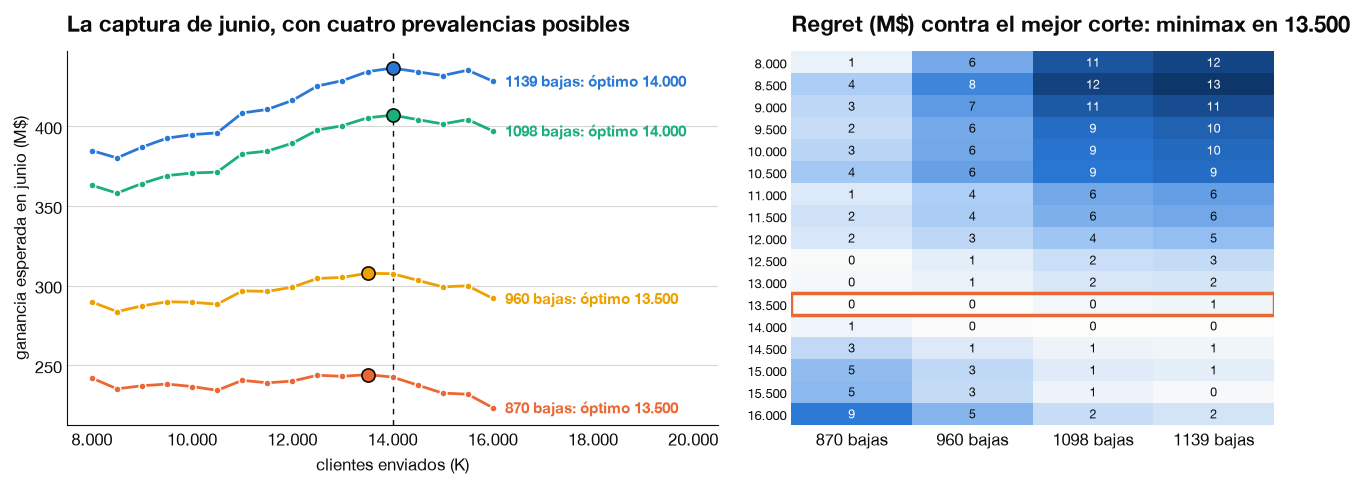

In [10]:
cap = pd.read_parquet("../experimentos/c216_captura_foldB/captura_foldB.parquet")
reg = pd.read_csv("../experimentos/c216_captura_foldB/regret.csv").set_index("K")
PREV = [870, 960, 1098, 1139]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.35, 1]})
colores = [NARANJA, AMARILLO, AQUA, AZUL]
for P, col in zip(PREV, colores):
    g = (cap.captura * P * 1.0725 - (cap.K - cap.captura * P) * 0.0275)
    a1.plot(cap.K, g, color=col, linewidth=2, marker="o", markersize=5, markeredgecolor="white", zorder=3)
    k = cap.K[g.idxmax()]
    a1.annotate(f" {P} bajas: óptimo {ve.num(k)}", (cap.K.iloc[-1], g.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=col, fontsize=10.5, fontweight="bold")
    a1.scatter([k], [g.max()], s=90, color=col, edgecolor=ve.TINTA, linewidth=1.2, zorder=4)
a1.axvline(14_000, color=ve.TINTA, linewidth=1, linestyle=(0, (4, 4)))
a1.set_xlabel("clientes enviados (K)"); a1.set_ylabel("ganancia esperada en junio (M$)"); a1.set_xlim(7_500, 20_500)
a1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: ve.num(x)))
a1.set_title("La captura de junio, con cuatro prevalencias posibles"); sin_marco(a1)
r = reg[[str(p) for p in PREV]]
im = a2.imshow(r.to_numpy(), aspect="auto", cmap=mpl.colors.LinearSegmentedColormap.from_list("b", ["#fcfcfb", "#9ec5f4", "#2a78d6", "#0d366b"]))
a2.set_yticks(range(len(r)), [ve.num(k) for k in r.index], fontsize=9.5); a2.set_xticks(range(4), [f"{p} bajas" for p in PREV])
for i, k in enumerate(r.index):
    for j, p in enumerate(PREV):
        val = r.iloc[i, j]; a2.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9, color="white" if val > r.to_numpy().max() * 0.55 else ve.TINTA)
mm = reg["peor"].idxmin(); a2.add_patch(mpl.patches.Rectangle((-0.5, list(r.index).index(mm) - 0.5), 4, 1, fill=False, edgecolor=NARANJA, linewidth=2.5))
a2.set_title(f"Regret (M$) contra el mejor corte: minimax en {ve.num(mm)}"); a2.tick_params(length=0)
for s in a2.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

**b. ¿La búsqueda bayesiana sobreajustó sus meses? (fold A, `c222`).** Optuna eligió hiperparámetros maximizando
AUC en junio y julio. El control: la receta y los cinco mejores trials, una semilla, entrenando solo marzo y
evaluando mayo, que la búsqueda nunca vio. El orden se da vuelta: el mejor trial de la búsqueda queda último en
mayo, y la receta primera. Con ~1.100 positivos por mes, el error muestral del AUC (~0,004) es del tamaño de la
"mejora" (0,003). Por eso la entrega usa la receta y no el trial ganador.

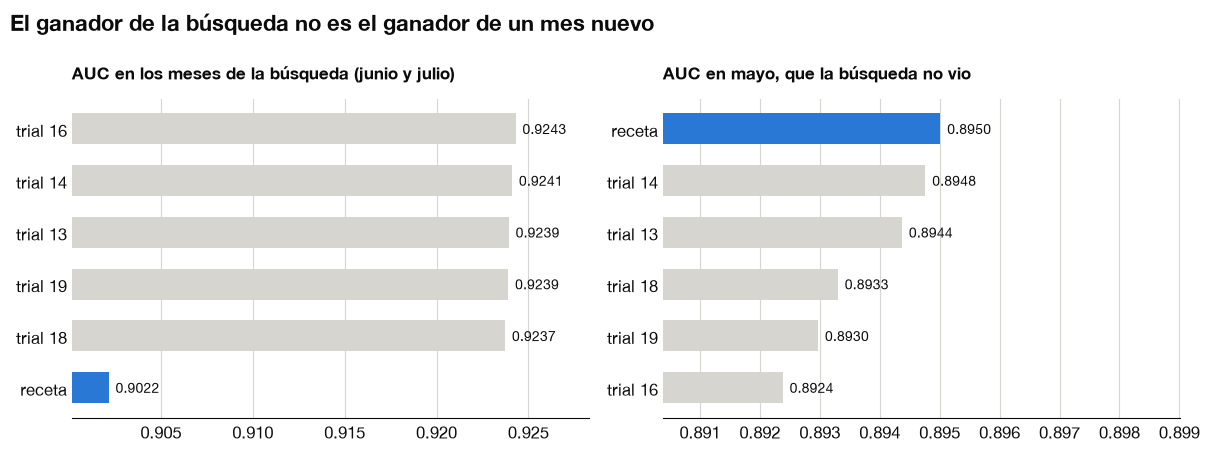

In [11]:
# del log de c222 (experimentos/c222_fold_A.log, no versionado): AUC en la busqueda (junio+julio) y AUC en mayo
ctrl = pd.DataFrame([("receta", 0.90215, 0.89501), ("trial 16", 0.92430, 0.89238), ("trial 14", 0.92411, 0.89476),
                     ("trial 13", 0.92393, 0.89437), ("trial 19", 0.92390, 0.89297), ("trial 18", 0.92373, 0.89330)],
                    columns=["config", "auc_busqueda", "auc_mayo"])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
for ax, col, titulo in ((a1, "auc_busqueda", "AUC en los meses de la búsqueda (junio y julio)"), (a2, "auc_mayo", "AUC en mayo, que la búsqueda no vio")):
    d = ctrl.sort_values(col, ascending=True)
    cols = [AZUL if c == "receta" else ve.GRILLA for c in d.config]
    ax.barh(d.config, d[col] - d[col].min() + 0.002, left=d[col].min() - 0.002, color=cols, height=0.6, zorder=3)
    for i, (cfg, val) in enumerate(zip(d.config, d[col])):
        ax.annotate(f"{val:.4f}", (val, i), xytext=(5, 0), textcoords="offset points", va="center", fontsize=10)
    ax.set_xlim(d[col].min() - 0.002, d[col].max() + 0.004); ax.set_title(titulo, fontsize=12.5)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.tick_params(length=0); ax.grid(axis="x", color=ve.GRILLA, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
fig.suptitle("El ganador de la búsqueda no es el ganador de un mes nuevo", x=0.01, ha="left", fontsize=16, fontweight="bold")
fig.tight_layout(); plt.show()

**c. ¿La validación local predijo el público?** En la primera semana cada experimento se validaba en junio
(ganancia local con los modelos entrenados en 03–04 o en 03–06) antes de mandarlo. Seis experimentos tienen las dos
medidas. Localmente estaban todos entre 316 y 332 M; en el público, entre 87,6 y 92,5. La correlación es nula: la
validación interna de un solo mes no distinguía entre variantes, y lo que terminó moviendo el público (los lags)
**no se podía ver localmente**, porque marzo no tiene mes anterior. Esa es la lección que llevó a medir con el bot
y 20 semillas.

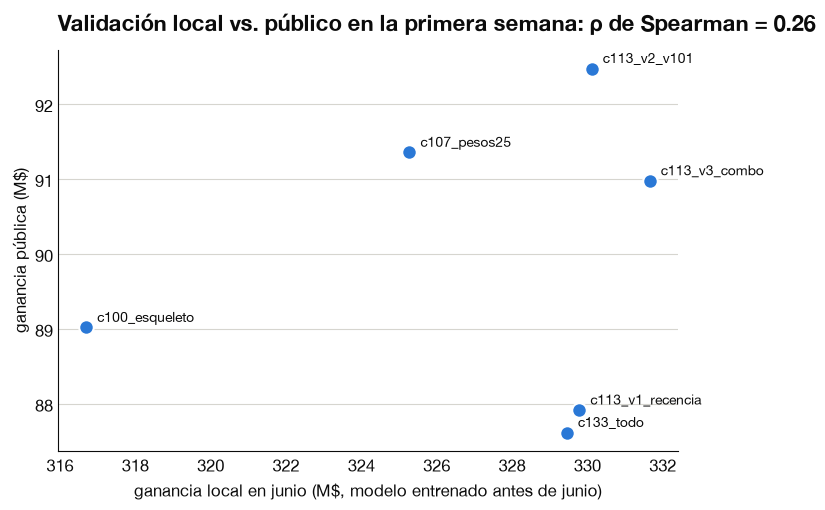

In [12]:
e = pd.read_csv("../ledger/experimento.csv")
pares = [("c100_esqueleto", "c100_esqueleto"), ("base_pesos25", "c107_pesos25"), ("c113_v1_recencia", "c113_v1_recencia"),
         ("c113_v2_v101", "c113_v2_v101"), ("c113_v3_combo", "c113_v3_combo"), ("c133_todo", "c133_todo")]
rows = []
for ex, sub in pares:
    loc = e[e.nombre == ex].ganancia_val_media.iloc[0]; loc = loc / 1e6 if loc > 1e4 else loc
    rows.append((sub, loc, v[v.submit == sub].public_gain_mean.iloc[0]))
d = pd.DataFrame(rows, columns=["submit", "local", "publico"])
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.scatter(d.local, d.publico, s=110, color=AZUL, edgecolor="white", linewidth=1.5, zorder=3)
for _, r in d.iterrows():
    ax.annotate(r.submit, (r.local, r.publico), xytext=(8, 4), textcoords="offset points", fontsize=10)
rho = d[["local", "publico"]].corr(method="spearman").iloc[0, 1]
ax.set_xlabel("ganancia local en junio (M$, modelo entrenado antes de junio)"); ax.set_ylabel("ganancia pública (M$)")
ax.set_title(f"Validación local vs. público en la primera semana: ρ de Spearman = {rho:.2f}")
sin_marco(ax); plt.show()

## 9. En qué se gastó el cupo

Submits por día del bot (el contador se renueva a las 21:00, así que el "día" va de 21:00 a 21:00 y se rotula
con la fecha en que termina) y el cupo de ese día. La fecha de cada submit es la del mensaje al bot en Zulip.

/var/folders/6f/kdr607jn1tsgt0hhgtsb3n400000gn/T/ipykernel_32115/843074173.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  dia = (fechados.enviado_en + pd.Timedelta(hours=3)).dt.date


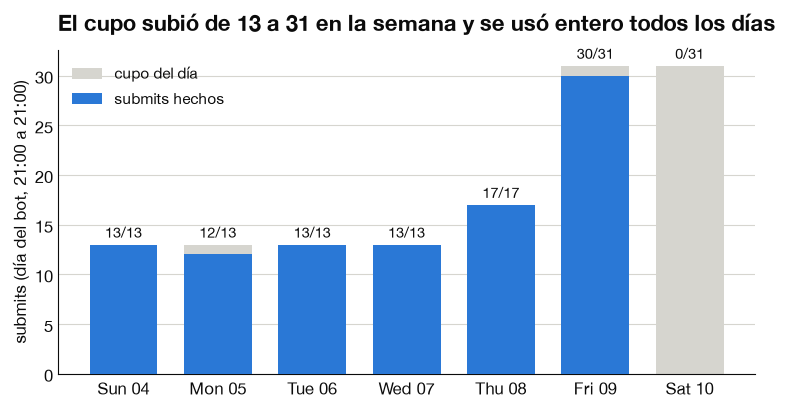

In [13]:
dia = (fechados.enviado_en + pd.Timedelta(hours=3)).dt.date
por_dia = dia.value_counts().sort_index()
cupo = {pd.Timestamp(f"2026-10-{d:02d}").date(): c for d, c in ((4, 13), (5, 13), (6, 13), (7, 13), (8, 17), (9, 31), (10, 31))}  # el bot lo fue subiendo durante la semana
dias = sorted(set(por_dia.index) | set(cupo))
usados = [por_dia.get(d, 0) for d in dias]
tope = [cupo.get(d, np.nan) for d in dias]
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(dias))
ax.bar(x, tope, color=ve.GRILLA, width=0.72, zorder=1, label="cupo del día")
ax.bar(x, usados, color=AZUL, width=0.72, zorder=3, label="submits hechos")
for xi, u, t in zip(x, usados, tope):
    ax.annotate(f"{u}/{int(t)}" if t == t else str(u), (xi, max(u, t if t == t else 0)), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10.5)
ax.set_xticks(x, [pd.Timestamp(d).strftime("%a %d") for d in dias])
ax.set_ylabel("submits (día del bot, 21:00 a 21:00)"); ax.legend(loc="upper left", frameon=False)
ax.set_title("El cupo subió de 13 a 31 en la semana y se usó entero todos los días")
sin_marco(ax); 
plt.show()